In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [28]:
class_data = pd.read_csv(
    "data/class.tsv",
    sep="\t",
    header=None
)

gene_expression = pd.read_csv(
    "data/filtered.tsv.gz",
    sep="\t",
    compression="gzip"
)

gene_mapping = pd.read_csv(
    "data/columns.tsv.gz",
    sep="\t",
    compression="gzip",
    comment="#"
)

In [29]:
print(gene_mapping.head())
print(gene_mapping.columns)

   ID               TYPE     ReporterID  \
0   1  cDNA_landinglight  IMAGE:2580289   
1   2  cDNA_landinglight  IMAGE:2580289   
2   3         cDNA_clone   BC DDP 2 E12   
3   4         cDNA_clone   BC DDP 2 G12   
4   5         cDNA_clone   BC TAX 1 A06   

                                           GeneName GeneSymbol UniGeneCluster  \
0                                       B-actin_1/4       ACTB      Hs.520640   
1                                       B-actin_1/8       ACTB      Hs.520640   
2                   AL122097 DKFZp434P1215(unknown)        NaN            NaN   
3                                           strange        NaN            NaN   
4  XM_017216 hypothetical protein FLJ21127(unknown)        NaN            NaN   

   UniGeneBuild               GB_LIST EntrezGene       vector  InsertLength  \
0         188.0  AW081870,  NM_001101         60  pCMV-SPORT6           NaN   
1         188.0  AW081870,  NM_001101         60  pCMV-SPORT6           NaN   
2           NaN  

In [30]:
genes_of_interest = gene_mapping[
    gene_mapping["GeneSymbol"].isin(
        ["XBP1", "GATA3"]
    )
]

print(genes_of_interest)

        ID        TYPE    ReporterID                 GeneName GeneSymbol  \
4358  4359  cDNA_clone  IMAGE:365681   GATA binding protein 3      GATA3   
4403  4404  cDNA_clone  IMAGE:417867  X-box binding protein 1       XBP1   

     UniGeneCluster  UniGeneBuild                  GB_LIST EntrezGene  \
4358      Hs.524134         188.0  AA025379,  NM_001002295       2625   
4403      Hs.437638         188.0       W90128,  NM_005080       7494   

         vector  InsertLength  ARRAY_BLOCK  BLOCK_COLUMN  BLOCK_ROW SPOT_ID  \
4358  pT3T7-Pac         779.0          8.0          15.0       14.0     NaN   
4403  pT3T7-Pac        1310.0          8.0          12.0       16.0     NaN   

     CLONE_ID  
4358      NaN  
4403      NaN  


In [31]:
print(gene_expression.columns[:20])

Index(['    1', '    2', '    6', '   12', '   13', '   15', '   16', '   17',
       '   20', '   25', '   28', '   33', '   34', '   36', '   38', '   43',
       '   46', '   49', '   52', '   54'],
      dtype='str')


In [32]:
print("4359" in gene_expression.columns)
print("4404" in gene_expression.columns)

False
False


In [33]:
print(gene_expression.shape)

(105, 16174)


In [34]:
print(gene_expression.head())

        1       2       6      12      13      15      16      17      20  \
0  0.0534  0.2558 -1.1449 -0.3843  0.4021  0.3512 -0.9012  0.7222 -0.7375   
1  0.4866  0.4736 -0.1135  0.1500  0.6200 -0.0146 -0.8901  0.2130 -0.6469   
2  0.5908  0.6439 -0.7664 -0.5907 -1.0596  1.2956 -3.7167  1.3004 -1.6517   
3 -0.4971 -0.4926 -0.8767 -0.3029 -0.4014  0.7181 -0.5141  1.1114 -0.8361   
4  0.2970  0.2770 -0.6193 -0.3508  0.0383 -0.2477  0.0367  0.5746 -0.6916   

       25  ...   27622   27623   27633   27634   27638   27641   27642  \
0  0.2280  ... -0.2210  0.5787  0.7728  0.0400 -0.9146  0.6340  0.6287   
1  0.4252  ... -0.0877  0.5425  0.4749 -0.3254 -0.1769  0.4156  0.7505   
2  0.5212  ...  0.4996  0.9947  1.6248 -1.5840 -0.8922  0.2501  0.7772   
3 -0.5792  ... -0.2264  0.8984  1.2040 -0.3831 -0.0856  0.9370  0.2867   
4  0.2816  ...  0.5279  0.9044 -0.0447  0.0892  0.1246  0.6882  1.0088   

    27643   27644   27648  
0  1.2642 -1.0183  0.0125  
1  1.0079 -0.3954  0.6992  
2  0.971

In [35]:
print(
    gene_mapping[
        gene_mapping["GeneSymbol"] == "GATA3"
    ][["ID", "GeneSymbol", "EntrezGene"]]
)

print(
    gene_mapping[
        gene_mapping["GeneSymbol"] == "XBP1"
    ][["ID", "GeneSymbol", "EntrezGene"]]
)

        ID GeneSymbol EntrezGene
4358  4359      GATA3       2625
        ID GeneSymbol EntrezGene
4403  4404       XBP1       7494


In [36]:
print('2625' in gene_expression.columns)
print('7494' in gene_expression.columns)

False
False


In [37]:
matching_cols = [
    col for col in gene_expression.columns
    if "2625" in str(col) or "7494" in str(col)
]

print(matching_cols)

[' 2625', ' 7494', '26250', '26251', '26252', '26258', '26259']


In [38]:
print(type(gene_expression.columns[0]))

<class 'str'>


In [39]:
gene_expression.columns = gene_expression.columns.str.strip()

In [40]:
print('2625' in gene_expression.columns)
print('7494' in gene_expression.columns)

True
True


In [41]:
gata3_expression = gene_expression['2625']

xbp1_expression = gene_expression['7494']

labels = class_data[0]

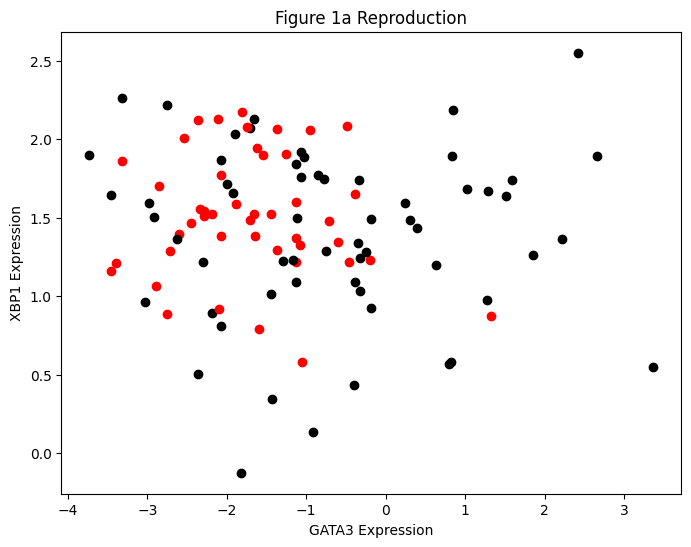

In [42]:
plt.figure(figsize=(8,6))

for i in range(len(labels)):

    if labels[i] == 1:
        color = "red"
    else:
        color = "black"

    plt.scatter(
        gata3_expression[i],
        xbp1_expression[i],
        c=color
    )

plt.xlabel("GATA3 Expression")
plt.ylabel("XBP1 Expression")

plt.title("Figure 1a Reproduction")

plt.show()

In [ ]:
# Interpretation of Figure 1a

The scatter plot shows the relationship between GATA3 and XBP1 expression levels across breast cancer patient samples.

Samples are colored according to tumor subtype:
- Red: ER+ breast cancer
- Black: ER− breast cancer

The plot demonstrates partial separation between the two classes, suggesting that expression patterns of GATA3 and XBP1 are associated with estrogen receptor status.

This reproduces the biological trend shown in Figure 1a of the referenced study.

In [43]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(gene_expression)

In [44]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)

In [45]:
print(principal_components.shape)

(105, 2)


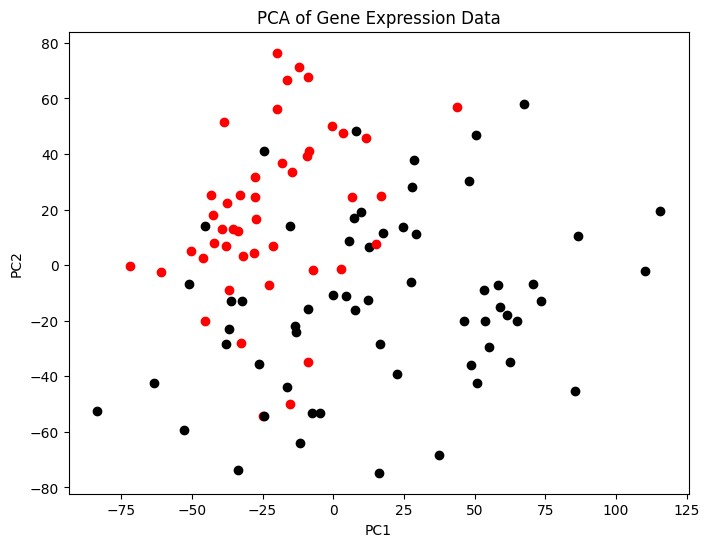

In [46]:
plt.figure(figsize=(8,6))

for i in range(len(labels)):

    if labels[i] == 1:
        color = "red"
    else:
        color = "black"

    plt.scatter(
        principal_components[i, 0],
        principal_components[i, 1],
        c=color
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA of Gene Expression Data")

plt.show()

In [47]:
print(pca.explained_variance_ratio_)

[0.10202316 0.07382828]


In [ ]:
# Interpretation of PCA Results

Principal Component Analysis (PCA) was applied to the standardized gene-expression matrix containing 105 breast cancer samples.

The PCA projection shows clustering patterns between ER+ and ER− tumor samples, indicating that global transcriptomic variation captures biologically meaningful subtype differences.

PC1 and PC2 summarize the dominant axes of variation in the dataset and reduce the high-dimensional gene-expression matrix into a lower-dimensional representation suitable for visualization and exploratory analysis.

This demonstrates the utility of PCA in transcriptomics and cancer subtype characterization.